<a href="https://colab.research.google.com/github/mtballestar/PythonTrainingSession/blob/CasoZara/CasoZara.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

# 1. Cargar el fichero original
# Si estás en Colab, antes sube el fichero y usa el nombre correcto (por ejemplo "fastfashion.xlsx")
input_file = "fastfashion.xlsx"   # cambia el nombre si es distinto
df = pd.read_excel(input_file)

# 2. Reemplazar los valores "<1" por 0.5 en Temu y Shein
cols_to_fix = ["temu", "shein"]

for col in cols_to_fix:
    # Sustituimos el texto "<1" por el valor numérico 0.5
    df[col] = df[col].replace("<1", 0.5)
    # Aseguramos que la columna es numérica (por si quedara algún string)
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 3. (Opcional) Comprobar si quedan nulos o valores no numéricos
print("Nulos por columna después de la limpieza:")
print(df[["zara", "shein", "temu"]].isna().sum())
print()

# 4. Guardar el fichero limpio
output_file = "fastfashion_clean.xlsx"
df.to_excel(output_file, index=False)
print(f"Fichero limpio guardado como: {output_file}")

# 5. (Opcional) Generar tablas de frecuencias para cada marca
freq_zara = df["zara"].value_counts().sort_index()
freq_shein = df["shein"].value_counts().sort_index()
freq_temu = df["temu"].value_counts().sort_index()

print("\nFrecuencias - Zara")
print(freq_zara)

print("\nFrecuencias - Shein")
print(freq_shein)

print("\nFrecuencias - Temu")
print(freq_temu)


Nulos por columna después de la limpieza:
zara     0
shein    0
temu     0
dtype: int64

Fichero limpio guardado como: fastfashion_clean.xlsx

Frecuencias - Zara
zara
7       3
8       8
9      10
10     16
11     19
       ..
93      2
94      1
95      1
98      1
100     1
Name: count, Length: 64, dtype: int64

Frecuencias - Shein
shein
0.0     97
0.5     45
1.0     11
2.0      7
3.0      5
4.0      4
5.0      5
6.0      6
7.0      6
8.0      6
9.0      1
10.0     1
11.0     3
13.0     3
15.0     3
18.0     3
19.0     2
20.0     2
21.0     3
22.0     2
23.0     3
24.0     3
25.0     1
26.0     5
27.0     4
28.0     5
29.0     5
30.0     6
32.0     4
33.0     1
34.0     2
35.0     1
36.0     1
39.0     2
40.0     1
43.0     2
44.0     1
45.0     1
Name: count, dtype: int64

Frecuencias - Temu
temu
0.0     216
0.5      16
4.0       1
5.0       1
6.0       2
7.0       2
9.0       2
10.0      1
11.0      5
12.0      2
13.0      6
14.0      3
15.0      2
18.0      3
19.0      1
Name: cou

/tmp/ipython-input-1686294197.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace("<1", 0.5)


In [5]:
# ============================================================
# EDA GOOGLE TRENDS: ZARA · SHEIN · TEMU (España, mensual)
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. CARGA DE DATOS Y LIMPIEZA BÁSICA
# ------------------------------------------------------------

# Nombre del fichero original descargado de Google Trends
# (ajústalo si tu fichero tiene otro nombre)
file_path = "fastfashion.xlsx"

# Cargamos el Excel
df = pd.read_excel(file_path)

# Visualizamos las primeras filas para comprobar estructura
print("Primeras filas del dataset:\n")
print(df.head(), "\n")

# Comprobamos nombres de columnas
print("Columnas del dataset:", df.columns.tolist(), "\n")

# ------------------------------------------------------------
# 2. LIMPIEZA ESPECÍFICA DE VALORES "<1" EN SHEIN Y TEMU
# ------------------------------------------------------------
# Google Trends a veces exporta "<1" como texto. Lo interpretamos como 0.5.

cols_to_fix = ["shein", "temu"]

for col in cols_to_fix:
    # Reemplazamos el texto "<1" por el valor numérico 0.5
    df[col] = df[col].replace("<1", 0.5)
    # Nos aseguramos de que la columna es numérica
    df[col] = pd.to_numeric(df[col], errors="coerce")

# También nos aseguramos de que zara sea numérica
df["zara"] = pd.to_numeric(df["zara"], errors="coerce")

# Comprobamos si hay nulos tras la conversión
print("Número de valores nulos después de la limpieza:")
print(df[["zara", "shein", "temu"]].isna().sum(), "\n")

# (Opcional) eliminar filas con nulos si los hubiera
# df = df.dropna(subset=["zara", "shein", "temu"])

# ------------------------------------------------------------
# 3. ANÁLISIS UNIVARIANTE (DESCRIPTIVO INDIVIDUAL)
# ------------------------------------------------------------

# Descriptivos básicos
desc = df[["zara", "shein", "temu"]].describe()
print("Estadísticos descriptivos básicos (media, std, min, max, cuartiles):\n")
print(desc, "\n")

# Mediana
medians = df[["zara", "shein", "temu"]].median()
print("Medianas:\n", medians, "\n")

# Asimetría (skewness): positiva = cola a la derecha, negativa = cola a la izquierda
skewness = df[["zara", "shein", "temu"]].skew()
print("Asimetría (skewness):\n", skewness, "\n")

# Podrías añadir otros estadísticos si quieres (kurtosis, etc.)
# kurtosis = df[["zara", "shein", "temu"]].kurtosis()

# ------------------------------------------------------------
# 4. FECHAS DE APARICIÓN DE SHEIN Y TEMU
# ------------------------------------------------------------
# Identificamos el primer mes con valor > 0 para cada una

first_shein_idx = df.index[df["shein"] > 0].min()
first_temu_idx  = df.index[df["temu"] > 0].min()

first_shein_date = df.loc[first_shein_idx, "Mes"] if pd.notna(first_shein_idx) else None
first_temu_date  = df.loc[first_temu_idx, "Mes"] if pd.notna(first_temu_idx) else None

print(f"Primer mes con SHEIN > 0: {first_shein_date}")
print(f"Primer mes con TEMU  > 0: {first_temu_date}\n")

# ------------------------------------------------------------
# 5. ANÁLISIS MULTIVARIANTE – CORRELACIÓN (PERIODO COMPLETO)
# ------------------------------------------------------------
# Correlación de Pearson en todo el período disponible

corr_full = df[["zara", "shein", "temu"]].corr(method="pearson")

print("Matriz de correlación (periodo completo):\n")
print(corr_full, "\n")

# ------------------------------------------------------------
# 6. CORRELACIÓN CUANDO ZARA Y SHEIN COEXISTEN (SHEIN > 0)
# ------------------------------------------------------------

mask_zara_shein = df["shein"] > 0
df_zara_shein_period = df.loc[mask_zara_shein, ["zara", "shein"]]

corr_zara_shein_period = df_zara_shein_period.corr()

print("Matriz de correlación ZARA–SHEIN (solo periodo con SHEIN > 0):\n")
print(corr_zara_shein_period, "\n")

# ------------------------------------------------------------
# 7. CORRELACIÓN CUANDO LAS TRES COEXISTEN (TEMU > 0)
# ------------------------------------------------------------

mask_three = df["temu"] > 0
df_three_period = df.loc[mask_three, ["zara", "shein", "temu"]]

corr_three_period = df_three_period.corr()

print("Matriz de correlación ZARA–SHEIN–TEMU (solo periodo con TEMU > 0):\n")
print(corr_three_period, "\n")

# ------------------------------------------------------------
# 8. RESUMEN INTERPRETABLE (OPCIONAL)
# ------------------------------------------------------------
# Aquí puedes añadir prints más narrativos si quieres que el notebook
# se lea casi como un informe.

print("Resumen rápido interpretativo:")
print("- Periodo completo: correlaciones globales entre las 3 marcas.")
print("- Periodo SHEIN > 0: relación competitiva/complementaria entre Zara y Shein cuando Shein ya es relevante.")
print("- Periodo TEMU > 0: cómo cambia la relación entre las tres cuando entra Temu en el juego.\n")


Primeras filas del dataset:

       Mes  zara temu shein
0  2004-01     8    0     0
1  2004-02     9    0     0
2  2004-03     8    0     0
3  2004-04     9    0     0
4  2004-05     8    0     0 

Columnas del dataset: ['Mes', 'zara', 'temu', 'shein'] 

Número de valores nulos después de la limpieza:
zara     0
shein    0
temu     0
dtype: int64 

Estadísticos descriptivos básicos (media, std, min, max, cuartiles):

             zara       shein        temu
count  263.000000  263.000000  263.000000
mean    44.148289    7.857414    1.418251
std     24.927775   11.968773    4.016185
min      7.000000    0.000000    0.000000
25%     13.000000    0.000000    0.000000
50%     50.000000    0.500000    0.000000
75%     63.000000   12.000000    0.000000
max    100.000000   45.000000   19.000000 

Medianas:
 zara     50.0
shein     0.5
temu      0.0
dtype: float64 

Asimetría (skewness):
 zara    -0.157774
shein    1.392961
temu     2.829979
dtype: float64 

Primer mes con SHEIN > 0: 2004-07


/tmp/ipython-input-2858675411.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace("<1", 0.5)


Primeras filas del dataset:
       Mes  zara temu shein
0  2004-01     8    0     0
1  2004-02     9    0     0
2  2004-03     8    0     0
3  2004-04     9    0     0
4  2004-05     8    0     0 

Columnas: ['Mes', 'zara', 'temu', 'shein'] 

Nulos por columna después de la limpieza numérica:
zara     0
shein    0
temu     0
dtype: int64 



/tmp/ipython-input-3916230450.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace("<1", 0.5)          # reemplazamos texto por número


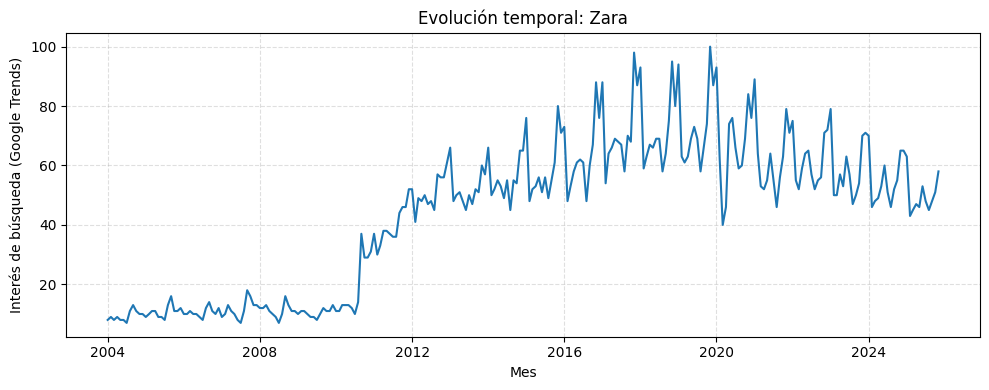

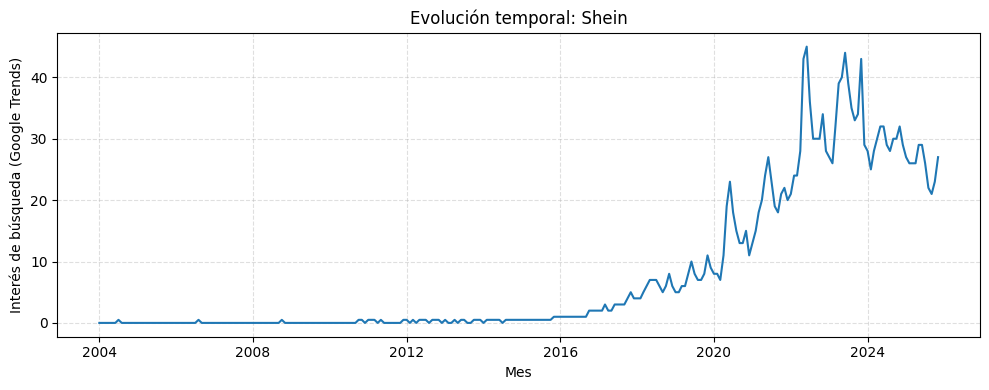

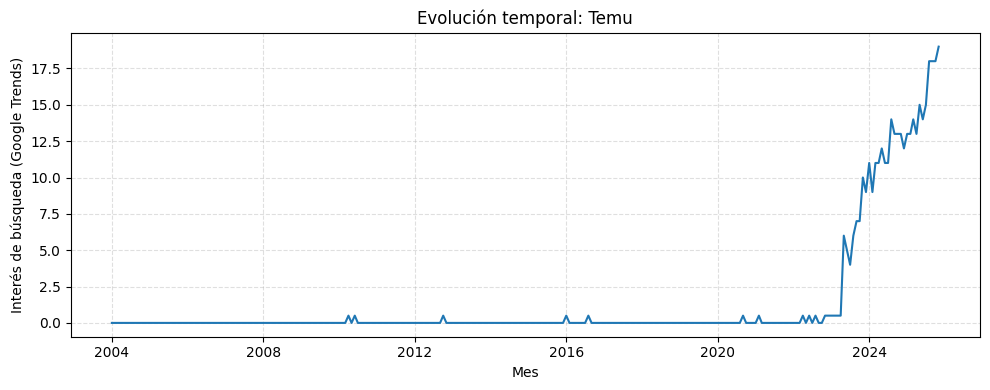

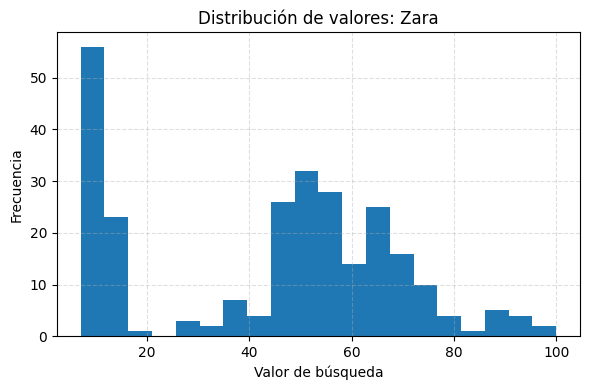

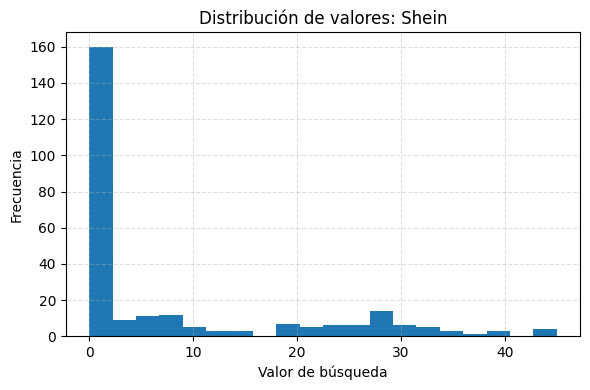

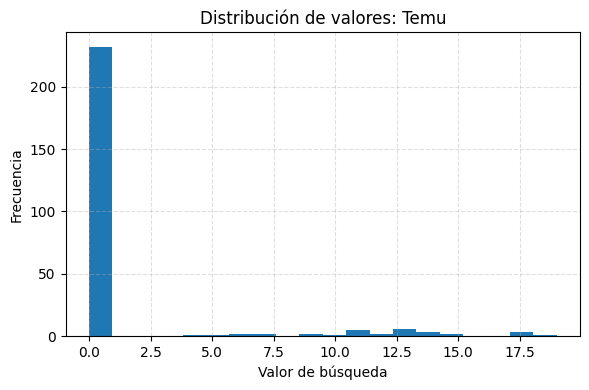

/tmp/ipython-input-3916230450.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


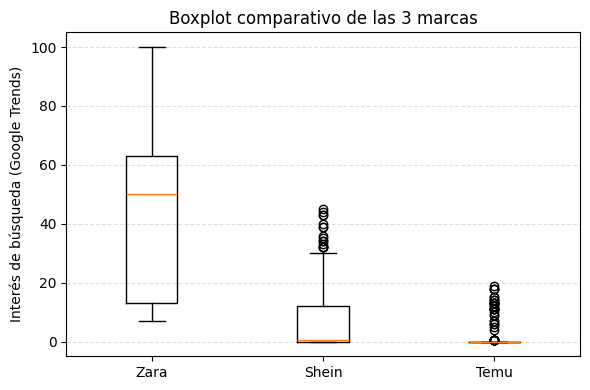

In [6]:
# ============================================================
# EDA VISUAL GOOGLE TRENDS: ZARA · SHEIN · TEMU
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. CARGA DE DATOS
# ------------------------------------------------------------

# Nombre del fichero descargado de Google Trends
file_path = "fastfashion.xlsx"   # cámbialo si tu fichero tiene otro nombre

# Cargamos el Excel
df = pd.read_excel(file_path)

print("Primeras filas del dataset:")
print(df.head(), "\n")
print("Columnas:", df.columns.tolist(), "\n")

# ------------------------------------------------------------
# 2. LIMPIEZA: TRATAR VALORES \"<1\" EN SHEIN Y TEMU
# ------------------------------------------------------------
# Google Trends puede exportar \"<1\" como texto. Lo interpretamos como 0.5.

cols_to_fix = ["shein", "temu"]

for col in cols_to_fix:
    df[col] = df[col].replace("<1", 0.5)          # reemplazamos texto por número
    df[col] = pd.to_numeric(df[col], errors="coerce")  # aseguramos tipo numérico

# Aseguramos también que zara es numérica
df["zara"] = pd.to_numeric(df["zara"], errors="coerce")

# (Opcional) comprobamos nulos tras la limpieza
print("Nulos por columna después de la limpieza numérica:")
print(df[["zara", "shein", "temu"]].isna().sum(), "\n")

# ------------------------------------------------------------
# 3. FORMATEO DE LA COLUMNA DE FECHA
# ------------------------------------------------------------

# Intentamos convertir 'Mes' a datetime (si no lo estuviera)
if "Mes" in df.columns:
    df["Mes"] = pd.to_datetime(df["Mes"])

# ------------------------------------------------------------
# 4. SERIES TEMPORALES: UNA GRÁFICA POR MARCA
# ------------------------------------------------------------
# Objetivo: ver la evolución del interés en el tiempo para cada marca.

for col in ["zara", "shein", "temu"]:
    plt.figure(figsize=(10, 4))
    plt.plot(df["Mes"], df[col])
    plt.title(f"Evolución temporal: {col.capitalize()}")
    plt.xlabel("Mes")
    plt.ylabel("Interés de búsqueda (Google Trends)")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 5. HISTOGRAMAS: DISTRIBUCIÓN DE VALORES PARA CADA MARCA
# ------------------------------------------------------------
# Objetivo: ver en qué rangos se concentran los valores de búsqueda.

for col in ["zara", "shein", "temu"]:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=20)
    plt.title(f"Distribución de valores: {col.capitalize()}")
    plt.xlabel("Valor de búsqueda")
    plt.ylabel("Frecuencia")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 6. BOXPLOT COMPARATIVO DE LAS 3 MARCAS
# ------------------------------------------------------------
# Objetivo: comparar mediana, rango intercuartílico y posibles outliers.

plt.figure(figsize=(6, 4))
plt.boxplot(
    [df["zara"], df["shein"], df["temu"]],
    labels=["Zara", "Shein", "Temu"]
)
plt.title("Boxplot comparativo de las 3 marcas")
plt.ylabel("Interés de búsqueda (Google Trends)")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2924285849.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace("<1", 0.5)


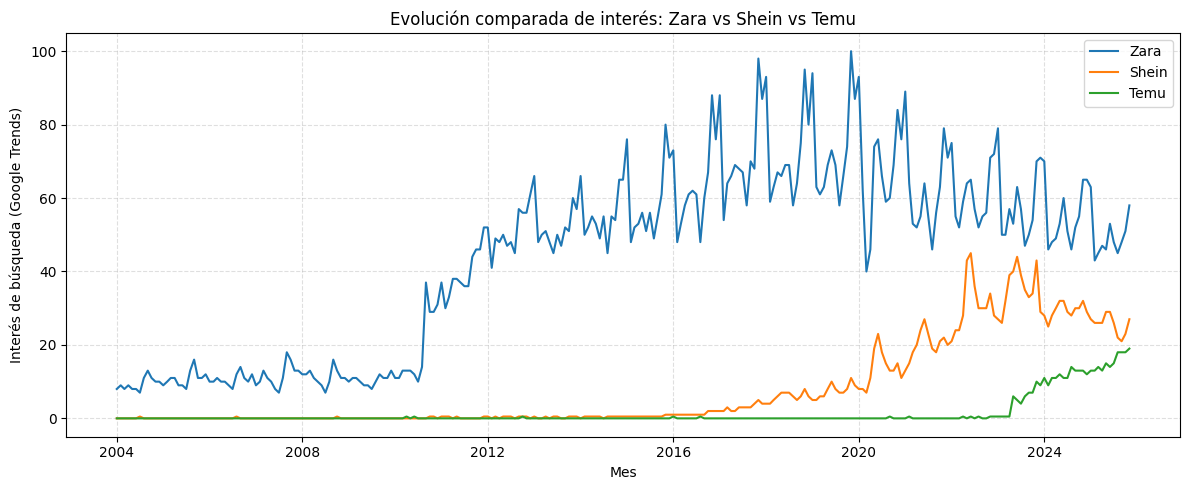

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. CARGA DEL FICHERO
# ------------------------------------------------------------
# Ajusta el nombre si tu fichero se llama de otra forma
file_path = "fastfashion.xlsx"

df = pd.read_excel(file_path)

# ------------------------------------------------------------
# 2. LIMPIEZA: TRATAR LOS "<1" Y ASEGURAR FORMATO NUMÉRICO
# ------------------------------------------------------------
# Google Trends exporta a veces "<1" como texto. Lo interpretamos como 0.5.

for col in ["shein", "temu"]:
    df[col] = df[col].replace("<1", 0.5)
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["zara"] = pd.to_numeric(df["zara"], errors="coerce")

# ------------------------------------------------------------
# 3. FORMATO DE FECHA
# ------------------------------------------------------------
# Convertimos la columna "Mes" a tipo fecha si es posible

df["Mes"] = pd.to_datetime(df["Mes"])

# Ordenamos por fecha por si acaso
df = df.sort_values("Mes")

# ------------------------------------------------------------
# 4. GRÁFICO COMPARADO ZARA · SHEIN · TEMU
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(df["Mes"], df["zara"],  label="Zara")
plt.plot(df["Mes"], df["shein"], label="Shein")
plt.plot(df["Mes"], df["temu"],  label="Temu")

plt.title("Evolución comparada de interés: Zara vs Shein vs Temu")
plt.xlabel("Mes")
plt.ylabel("Interés de búsqueda (Google Trends)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


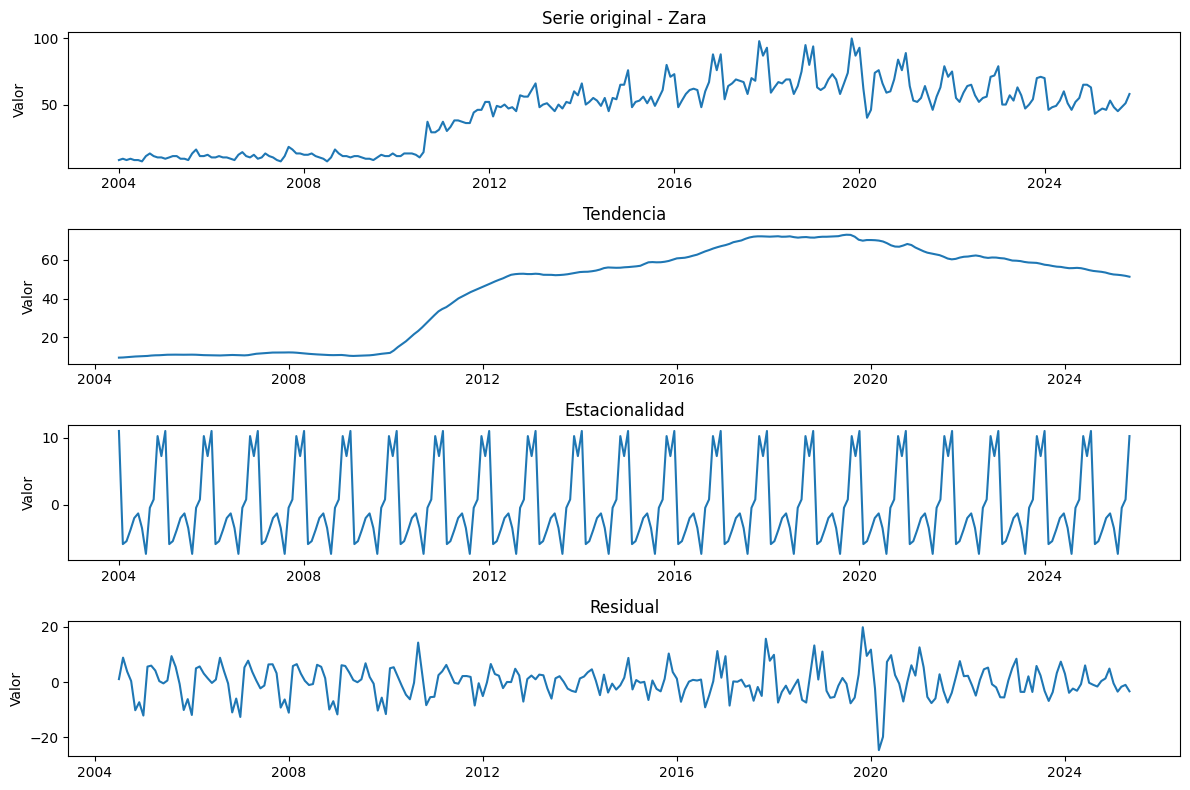

Componentes guardados en 'zara_decomposition.xlsx'


In [8]:
# ============================================================
# DESCOMPOSICIÓN DE LA SERIE TEMPORAL: ZARA
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# ------------------------------------------------------------
# 1. Cargar los datos
# ------------------------------------------------------------
# Ajusta el nombre del fichero si es distinto
file_path = "fastfashion.xlsx"

df = pd.read_excel(file_path)

# Nos aseguramos de que la columna de fecha se llama "Mes"
# y la convertimos a tipo datetime
df["Mes"] = pd.to_datetime(df["Mes"])

# Ordenamos por fecha por si acaso
df = df.sort_values("Mes")

# Nos aseguramos de que la serie de Zara es numérica
df["zara"] = pd.to_numeric(df["zara"], errors="coerce")

# Creamos una serie temporal con índice de fecha
zara_ts = df.set_index("Mes")["zara"]

# (Opcional pero recomendable) indicamos que es mensual
zara_ts = zara_ts.asfreq("MS")   # MS = Month Start; usar "M" si prefieres fin de mes

# ------------------------------------------------------------
# 2. Descomposición estacional
# ------------------------------------------------------------
# Usamos un modelo aditivo y periodo 12 (mensual → estacionalidad anual)
decomp = seasonal_decompose(zara_ts, model="additive", period=12)

# Los componentes están en:
# decomp.trend        → tendencia
# decomp.seasonal     → estacionalidad
# decomp.resid        → residuo

# ------------------------------------------------------------
# 3. Visualización de los componentes
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

# Serie original
plt.subplot(4, 1, 1)
plt.plot(zara_ts)
plt.title("Serie original - Zara")
plt.ylabel("Valor")

# Tendencia
plt.subplot(4, 1, 2)
plt.plot(decomp.trend)
plt.title("Tendencia")
plt.ylabel("Valor")

# Estacionalidad
plt.subplot(4, 1, 3)
plt.plot(decomp.seasonal)
plt.title("Estacionalidad")
plt.ylabel("Valor")

# Residual
plt.subplot(4, 1, 4)
plt.plot(decomp.resid)
plt.title("Residual")
plt.ylabel("Valor")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. (Opcional) Guardar los componentes en un Excel
# ------------------------------------------------------------
components = pd.DataFrame({
    "trend": decomp.trend,
    "seasonal": decomp.seasonal,
    "residual": decomp.resid
})

components.to_excel("zara_decomposition.xlsx")
print("Componentes guardados en 'zara_decomposition.xlsx'")
